# TP1 — Multiple Linear Regression
Working in pairs is acceptable; however, I strongly recommend submitting the assignment individually. The deadline for this first assignment is February 16, 2026. Please send your response to razan.mhanna@inria.fr
 only.


**Dataset:** Diabetes (regression)

## Learning objectives
- Construct a design matrix and add an intercept
- Fit a multiple linear regression model (OLS)
- Interpret coefficients, p-values, and $R^2$
- Make predictions with confidence intervals
- Perform basic diagnostic checks


## Question 1 — Load the dataset
1. Load the **Diabetes** regression dataset.
2. Convert it to a pandas DataFrame.
3. Identify:
   - the number of observations $n$
   - the number of predictors $p$

👉 *Write the code below.*

In [44]:
!pip -q install statsmodels scikit-learn pandas matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.datasets import load_diabetes
pd.set_option('display.precision', 4)
print('Ready!')

Ready!



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
diab = load_diabetes(as_frame=True)
df = diab.frame.copy()

In [46]:
df.info()
n = df.shape[0]
p = df.shape[1] - 1 

print("-" * 30)
print(f"Number of observations (n): {n}")
print(f"Number of predictors (p):   {p}")
print("-" * 30)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
------------------------------
Number of observations (n): 442
Number of predictors (p):   10
------------------------------


We have 442 servations and 10 predictors

## Question 2 — Define $X$ and $y$
1. Define the response variable $y$.
2. Define the predictor matrix $X$.
3. Add an intercept column to $X$.

👉 *Explain why adding a constant is necessary when using statsmodels.*

In [47]:
df['const'] = 1
df.head()
X = df.drop(columns=['target'])
y = df['target']
X = sm.add_constant(X)
display(X.head())
display(y.head())


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,const
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,1
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,1
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,1
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,1
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,1


0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

Without adding a constant, stastmodels assumes that the regression line must past from origin ((0,0)) which isn't correct for all models

## Question 3 — Fit the multiple linear regression model
1. Fit an **OLS** model using statsmodels.
2. Display the full regression summary.

👉 *Write down the estimated regression equation.*

In [48]:
model = sm.OLS(y, X) # It's y,X not X,y because of the way statsmodels works. It expects the dependent variable first and then the independent variables.
result = model.fit()
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Cmt, 14 Şub 2026   Prob (F-statistic):           3.83e-62
Time:                        00:49:04   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
age          -10.0099     59.749     -0.168      0.8

$$y = 152.1335 - 10.0099 \cdot \text{age} - 239.8156 \cdot \text{sex} + 519.8459 \cdot \text{bmi} + 324.3846 \cdot \text{bp} - 792.1756 \cdot s1 + 476.7390 \cdot s2 + 101.0433 \cdot s3 + 177.0632 \cdot s4 + 751.2737 \cdot s5 + 67.6267 \cdot s6$$


## Question 4 — Interpretation of coefficients
Using the regression output:
1. Which predictors are statistically significant at the 5% level?
2. Interpret **one significant coefficient** in words.
3. Is the intercept meaningful in this context? Explain.

$$ \text{1. We will look to the P>|t| column and if it's } < 0.05 \quad \text{ then we reject null hypothesis so they are statistically significant} \\
\text{For us sex,bmi,bp and s5 are statistically significant based on result.summary()}\\

\text{2. bp is blood pressure and by looking at coeffs we can see that bp's coeff is 324.3846 so this means if all the other coeffs holds constant and if bp is increased by } \\
\text{ 1 unit, it will make the solution increased by 324.3846 unit} \\
\text{3. in real life if we take all the variables as 0 ,it means that the person is dead because bp and bmi is 0, but according to the equation y still equals to some value so} \\
\text{the intercept isn't meaningful in this context}

## Question 5 — Goodness of fit
1. What is the value of $R^2$?
2. What does $R^2$ represent in this model?
3. Compare $R^2$ and adjusted $R^2$. Why are they different?

$$ \text{1. By looking at result.summary() we can see $R^2$ = 0.518} \\
\text{2. $R^2$ measures how well a statistical model predicts an outcome which represented by the dependant variable. It is the propotion of variance in the} \\
\text{dependant variable (y)}\\
\text{3. $R^2$ = 0.518 and $Adj. R^2$ = 0.507. They are different because Adj.$R^2$ decreases if you add new variable to the model but $R^2$ doesn't, $R^2$ is bigger than $Adj. R^2$ } \\
\text{because there is one or multiple variables in the system isn't so valuable. Adj.$R^2$ is always smaller or equal than $R^2$ and they are equal if $R^2$ = 1 }

## Question 6 — Multicollinearity
1. Compute the correlation matrix of the predictors.
2. Identify any strongly correlated variables.

👉 *Explain how multicollinearity affects coefficient estimates.*

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.0000,0.1737,0.1851,0.3354,0.2601,0.2192,-0.0752,0.2038,0.2708,0.3017
sex,0.1737,1.0000,0.0882,0.2410,0.0353,0.1426,-0.3791,0.3321,0.1499,0.2081
bmi,0.1851,0.0882,1.0000,0.3954,0.2498,0.2612,-0.3668,0.4138,0.4462,0.3887
bp,0.3354,0.2410,0.3954,1.0000,0.2425,0.1855,-0.1788,0.2577,0.3935,0.3904
s1,0.2601,0.0353,0.2498,0.2425,1.0000,0.8967,0.0515,0.5422,0.5155,0.3257
s2,0.2192,0.1426,0.2612,0.1855,0.8967,1.0000,-0.1965,0.6598,0.3184,0.2906
s3,-0.0752,-0.3791,-0.3668,-0.1788,0.0515,-0.1965,1.0000,-0.7385,-0.3986,-0.2737
s4,0.2038,0.3321,0.4138,0.2577,0.5422,0.6598,-0.7385,1.0000,0.6179,0.4172
s5,0.2708,0.1499,0.4462,0.3935,0.5155,0.3184,-0.3986,0.6179,1.0000,0.4647
s6,0.3017,0.2081,0.3887,0.3904,0.3257,0.2906,-0.2737,0.4172,0.4647,1.0000


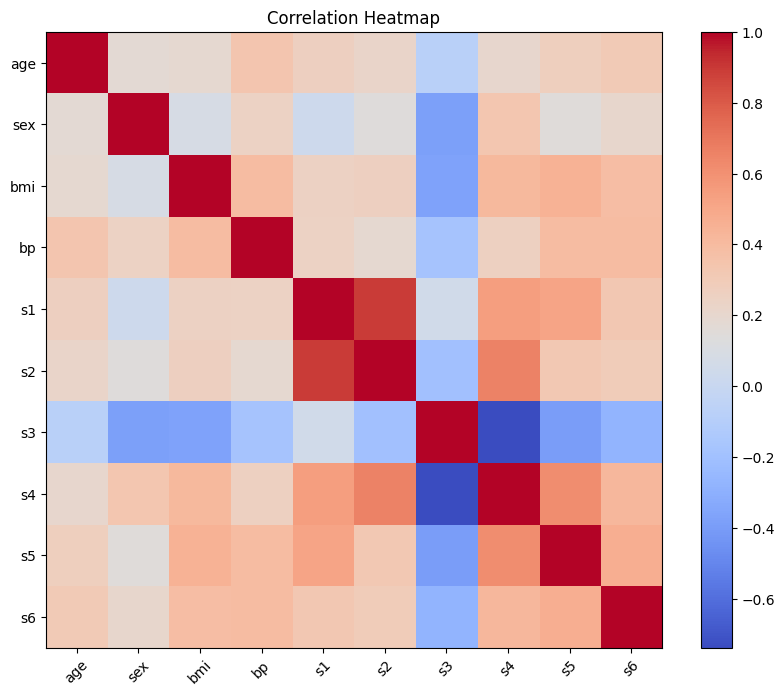

In [49]:
corr_matrix = X.drop(columns=['const']).corr()
display(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()

$$ \text{1. corr(s1,s2) = 0.89 , corr(s3,s4) = -0.73 , corr(s2,s4) = 0.65 are some strongely correlated variables} \\
\text{2. multicollinearity causes the coefficients to be very sensetive to the small changes in the model. It weakens the precision of the estimated coeffs and }\\
\text{makes the p-values non-trustworthy}

## Question 7 (Bonus) — Global significance of the model
1. State the null hypothesis tested by the **F-statistic**.
2. Based on the p-value, is the model globally significant?
3. What does this tell you about the predictors as a group?

In [50]:
f_stat = result.fvalue
f_p_value = result.f_pvalue

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value (Prob > F): {f_p_value:.4e}")

if f_p_value < 0.05:
    print("CONCLUSION: The model is GLOBALLY SIGNIFICANT. We reject H0.")
else:
    print("CONCLUSION: The model is NOT significant. We fail to reject H0.")

F-statistic: 46.2724
P-value (Prob > F): 3.8286e-62
CONCLUSION: The model is GLOBALLY SIGNIFICANT. We reject H0.


$$ \text{1. null hypothesis by the F-statistic is that all coefs are 0, so the model hasn't got any predictive power} \\
\text{2. P-value of F-statistic is 3.8286e-62 which is smaller than 0.05 so it is globally significant} \\
\text{3. Because F-statistic is globally significant, we can tell that predictors as a group is statistically significant }
